# Choice-only RLSSM tutorial

This tutorial is for readers who already know the basics of HSSM models and want to fit a reinforcement-learning model when the data contain choices and rewards, but no reaction times.

By the end you will be able to:

1. simulate a choice-only Rescorla-Wagner bandit with `ssms.rl`,
2. remove the ssms dummy `rt` compatibility column before HSSM inference,
3. bridge the ssms preset into HSSM with `RLSSMConfig.from_ssms_model(...)`,
4. fit hierarchical `rl_alpha` and `beta`, and
5. run posterior predictive checks with ssms response-only PPC.

The main example is `2AB_RW_InvTempSoftmax`: a two-armed Bernoulli bandit where trial-wise Q-values drive an inverse-temperature softmax choice rule. The analogous three-choice preset is `3AB_RW_InvTempSoftmax`.


## Setup

The notebook uses the same execution pattern as the PyMC6 RLSSM tutorials. `FULL_RUN=0` keeps documentation builds quick; `FULL_RUN=1` uses the richer settings that should be committed.


In [1]:
import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ssms import rl

import hssm

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

hssm.set_floatX("float32", update_jax=True)
RANDOM_SEED = 20260707

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

N_PARTICIPANTS = 15 if FULL_RUN else 5
N_TRIALS = 150 if FULL_RUN else 80
N_CHAINS = 2
N_TUNE = 1000 if FULL_RUN else 300
N_DRAWS = 500 if FULL_RUN else 300
N_PPC_DRAWS = 20 if FULL_RUN else 8
BIN_SIZE = 10

print(
    f"FULL_RUN={FULL_RUN} | participants={N_PARTICIPANTS} "
    f"trials={N_TRIALS} tune={N_TUNE} draws={N_DRAWS} "
    f"ppc_draws={N_PPC_DRAWS}"
)

FULL_RUN=True | participants=15 trials=150 tune=1000 draws=500 ppc_draws=20


## Pick the ssms choice-only RL preset

`ssms.rl` owns the model definition. HSSM consumes the preset metadata and provides the Bayesian inference layer.


In [3]:
MODEL_NAME = "2AB_RW_InvTempSoftmax"
ssms_config = rl.preset.get(MODEL_NAME)
assembled = ssms_config.assemble(backend="jax")
preset_info = rl.preset.info(MODEL_NAME)

summary = pd.Series(
    {
        "model": MODEL_NAME,
        "learning_process": preset_info["learning_process"],
        "decision_process": ssms_config.decision_process,
        "response": ssms_config.response,
        "choices": ssms_config.choices,
        "sampled_parameters": ssms_config.list_params,
        "computed_parameters": assembled.computed_params,
        "extra_fields": ssms_config.context_fields,
    }
)
print(summary.to_string())

assert ssms_config.response == ["response"]
assert ssms_config.list_params == ["rl_alpha", "beta"]
assert ssms_config.context_fields == ["feedback"]
assert ssms_config.decision_process == "inv_temp_softmax_2"
assert assembled.computed_params == ["q0", "q1"]

model                  2AB_RW_InvTempSoftmax
learning_process       RescorlaWagnerSoftmax
decision_process          inv_temp_softmax_2
response                          [response]
choices                               (0, 1)
sampled_parameters          [rl_alpha, beta]
computed_parameters                 [q0, q1]
extra_fields                      [feedback]


## Simulate data with participant-level variation

`rl_alpha` controls how quickly feedback updates Q-values. `beta` controls how strongly the current Q-values concentrate choice probability on the better-looking arm. The participant-level values below are clipped to parameter-specific bounds so every simulated participant is valid for the ssms preset.


In [4]:
GROUP_THETA = {
    "rl_alpha": 0.20,
    "beta": 3.5,
}
SDS = {
    "rl_alpha": 0.06,
    "beta": 0.70,
}
SIMULATION_BOUNDS = {
    "rl_alpha": (0.03, 0.70),
    "beta": (1.00, 7.00),
}
LIST_PARAMS = list(GROUP_THETA)

rng = np.random.default_rng(RANDOM_SEED)
theta_arrays = {
    name: np.clip(
        rng.normal(GROUP_THETA[name], SDS[name], N_PARTICIPANTS),
        *SIMULATION_BOUNDS[name],
    )
    for name in LIST_PARAMS
}

true_params = pd.DataFrame(theta_arrays)
true_params.index.name = "participant_id"
true_params.round(3)

,rl_alpha,beta
participant_id,,
0,0.247,2.852
1,0.289,3.875
2,0.247,3.567
3,0.161,3.335
4,0.067,3.216
5,0.133,2.752
6,0.184,2.524
7,0.291,3.020
8,0.188,3.718


In [5]:
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays,
    n_trials=N_TRIALS,
    n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)

assert np.all(data["rt"].to_numpy() == -1.0)
print("rows:", len(data), "| columns:", list(data.columns))
print("unique placeholder rt values:", sorted(data["rt"].unique()))
data.head()

rows: 2250 | columns: ['participant_id', 'trial_id', 'rt', 'response', 'feedback']
unique placeholder rt values: [np.float64(-1.0)]


,participant_id,trial_id,rt,response,feedback
0,0,0,-1.0,1,0.0
1,0,1,-1.0,0,0.0
2,0,2,-1.0,0,1.0
3,0,3,-1.0,0,0.0
4,0,4,-1.0,1,0.0


The `rt=-1.0` column is a dummy compatibility placeholder emitted by ssms for choice-only simulation. It is not an observed reaction time and must not be modeled by HSSM in this workflow. Before inference, keep only the response and RL context columns.


In [6]:
response_only_data = data.drop(columns=["rt"])
ssms_config.validate_data(response_only_data).raise_for_errors()

print("HSSM data columns:", list(response_only_data.columns))
response_only_data.head()

HSSM data columns: ['participant_id', 'trial_id', 'response', 'feedback']


,participant_id,trial_id,response,feedback
0,0,0,1,0.0
1,0,1,0,0.0
2,0,2,0,1.0
3,0,3,0,0.0
4,0,4,1,0.0


## Bridge the ssms model into HSSM

`RLSSMConfig.from_ssms_model(...)` turns the ssms preset into HSSM metadata: observed columns, sampled parameters, context fields, decision process, and computed Q-value functions.


In [7]:
model_config = hssm.rl.RLSSMConfig.from_ssms_model(MODEL_NAME)
computed_params = set(model_config.ssm_logp_func.computed)

bridge_summary = pd.Series(
    {
        "response": model_config.response,
        "list_params": model_config.list_params,
        "extra_fields": model_config.extra_fields,
        "decision_process": model_config.decision_process,
        "computed_params": sorted(computed_params),
    }
)
print(bridge_summary.to_string())

assert model_config.response == ["response"]
assert model_config.list_params == ["rl_alpha", "beta"]
assert model_config.extra_fields == ["feedback"]
assert model_config.decision_process == "inv_temp_softmax_2"
assert computed_params == {"q0", "q1"}

response                    [response]
list_params           [rl_alpha, beta]
extra_fields                [feedback]
decision_process    inv_temp_softmax_2
computed_params               [q0, q1]


### Exercise: inspect the three-choice preset

The three-choice version uses the same bridge pattern. The only structural changes are the decision process and the extra computed Q-value.


In [8]:
three_choice_config = hssm.rl.RLSSMConfig.from_ssms_model("3AB_RW_InvTempSoftmax")
three_choice_summary = pd.Series(
    {
        "response": three_choice_config.response,
        "list_params": three_choice_config.list_params,
        "extra_fields": three_choice_config.extra_fields,
        "decision_process": three_choice_config.decision_process,
        "computed_params": sorted(three_choice_config.ssm_logp_func.computed),
    }
)
three_choice_summary

response                    [response]
list_params           [rl_alpha, beta]
extra_fields                [feedback]
decision_process    inv_temp_softmax_3
computed_params           [q0, q1, q2]
dtype: object

## Build the hierarchical model

The sampled parameters are `rl_alpha` and `beta`. The Q-values `q0` and `q1` are computed inside the ssms replay and are not sampled as free HSSM parameters. We set `p_outlier=0` and `lapse=None` to keep the first tutorial focused on the core learning and softmax components.


In [9]:
PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal",
    "mu": 0,
    "sigma": {"name": "HalfNormal", "sigma": 0.35},
}


def hierarchical_param(name, lower, upper, mu, sigma):
    """Return a group intercept plus mean-zero participant deviations."""
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior(
                "TruncatedNormal",
                lower=lower,
                upper=upper,
                mu=mu,
                sigma=sigma,
            ),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )

In [10]:
model = hssm.RLSSM(
    data=response_only_data,
    model_config=model_config,
    p_outlier=0,
    lapse=None,
    process_initvals=False,
    include=[
        hierarchical_param("rl_alpha", 0.0, 1.0, 0.20, 0.12),
        hierarchical_param("beta", 0.0, 10.0, 3.5, 1.2),
    ],
)

print("participants:", model.n_participants, "| trials/participant:", model.n_trials)
print("free parameters:", list(model.params.keys()))
assert {"rl_alpha", "beta"}.issubset(model.params)
assert {"q0", "q1"}.isdisjoint(model.params)

You supplied a model '2AB_RW_InvTempSoftmax', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


participants: 15 | trials/participant: 150
free parameters: ['rl_alpha', 'beta']


## Sample the posterior

Choice-only data often identify group trends more strongly than every participant-level parameter. The full-run settings below give a more stable recovery display than the quick documentation scale.


In [11]:
idata = model.sample(
    sampler="numpyro",
    draws=N_DRAWS,
    tune=N_TUNE,
    chains=N_CHAINS,
    cores=1,
    target_accept=0.9,
    random_seed=RANDOM_SEED,
    idata_kwargs={"log_likelihood": False},
)
az.summary(
    idata,
    var_names=["rl_alpha_Intercept", "beta_Intercept"],
    kind="stats",
    ci_kind="hdi",
    ci_prob=0.94,
)

Using default initvals. 



NUTS[numpyro]: [rl_alpha_Intercept, rl_alpha_1|participant_id_sigma, rl_alpha_1|participant_id_offset, beta_Intercept, beta_1|participant_id_sigma, beta_1|participant_id_offset]


  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   5%|▌         | 75/1500 [00:01<00:36, 39.12it/s, 63 steps of size 5.59e-02. acc. prob=0.87]

warmup:  10%|█         | 150/1500 [00:02<00:20, 67.08it/s, 15 steps of size 3.01e-01. acc. prob=0.88]

...

sample: 100%|██████████| 1500/1500 [00:12<00:00, 118.45it/s, 63 steps of size 7.41e-02. acc. prob=0.97]

There were 16 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi94_lb,hdi94_ub
rl_alpha_Intercept,0.2,0.026,0.16,0.25
beta_Intercept,3.2,0.21,2.8,3.6


## Parameter recovery

The group plot checks whether the true group means fall in the posterior intervals. The participant plot is stricter: it compares each participant's true value to the posterior mean for that participant.


In [12]:
def posterior_dataset(idata):
    """Return posterior samples as an xarray Dataset."""
    posterior = idata.posterior
    if hasattr(posterior, "to_dataset"):
        posterior = posterior.to_dataset()
    return posterior


def group_recovery(idata, true_group):
    """Compare group intercept posteriors with true group means."""
    names = [f"{p}_Intercept" for p in LIST_PARAMS]
    summ = az.summary(
        idata,
        var_names=names,
        kind="stats",
        ci_kind="hdi",
        ci_prob=0.94,
        round_to="none",
    )
    summ.index = LIST_PARAMS
    summ["true"] = [true_group[p] for p in LIST_PARAMS]

    fig, ax = plt.subplots(figsize=(7, 3.2))
    y = np.arange(len(LIST_PARAMS))
    ax.errorbar(
        summ["mean"],
        y,
        xerr=[summ["mean"] - summ["hdi94_lb"], summ["hdi94_ub"] - summ["mean"]],
        fmt="o",
        capsize=4,
        label="posterior (94% HDI)",
    )
    ax.scatter(summ["true"], y, color="crimson", marker="D", zorder=5, label="true")
    ax.set_yticks(y)
    ax.set_yticklabels(LIST_PARAMS)
    ax.invert_yaxis()
    ax.set_title("Group-level recovery")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
    return summ


def participant_recovery(idata, true_params):
    """Plot per-participant true values against posterior-mean estimates."""
    post = posterior_dataset(idata)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
    correlations = {}

    for ax, name in zip(axes, LIST_PARAMS):
        re = post[f"{name}_1|participant_id"]
        pid_dim = [d for d in re.dims if d not in ("chain", "draw")][0]
        draws = post[f"{name}_Intercept"] + re
        rec_mean = draws.mean(("chain", "draw")).values
        lo = draws.quantile(0.03, ("chain", "draw")).values
        hi = draws.quantile(0.97, ("chain", "draw")).values
        ids = [int(v) for v in re[pid_dim].values]
        true_v = true_params.loc[ids, name].values

        ax.errorbar(
            true_v,
            rec_mean,
            yerr=[rec_mean - lo, hi - rec_mean],
            fmt="o",
            ecolor="0.7",
            capsize=3,
        )
        pad = 0.08 * max(np.ptp(true_v), np.ptp(rec_mean), 1e-6)
        lohi = [
            min(true_v.min(), rec_mean.min()) - pad,
            max(true_v.max(), rec_mean.max()) + pad,
        ]
        ax.plot(lohi, lohi, "k--", lw=1)
        ax.set_title(name)
        ax.set_xlabel("true")
        ax.set_ylabel("recovered")
        ax.grid(alpha=0.3)
        correlations[name] = float(np.corrcoef(true_v, rec_mean)[0, 1])

    fig.suptitle("Participant-level recovery")
    plt.show()
    return pd.Series(correlations, name="true_vs_recovered_correlation")

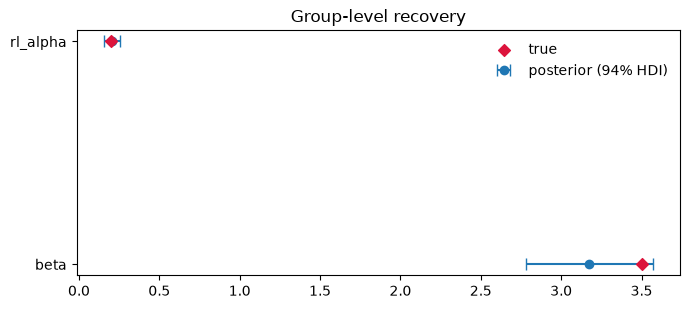

,mean,sd,hdi94_lb,hdi94_ub,true
rl_alpha,0.204748,0.026175,0.156764,0.253813,0.2
beta,3.174217,0.206127,2.782644,3.568842,3.5


In [13]:
group_summary = group_recovery(idata, GROUP_THETA)
group_summary

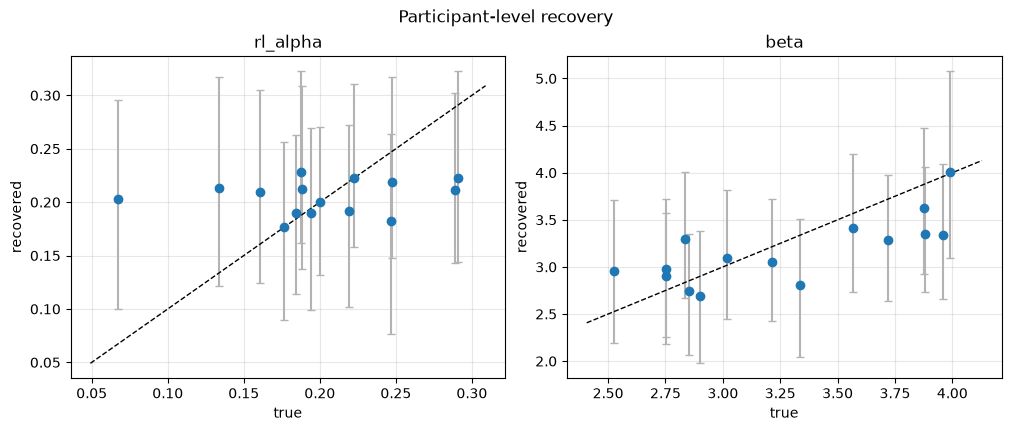

rl_alpha    0.166293
beta        0.753452
Name: true_vs_recovered_correlation, dtype: float64

In [14]:
participant_correlations = participant_recovery(idata, true_params)
participant_correlations

Participant-level `beta` can be harder to recover than the group mean because choices only reveal relative preference strength through a finite sequence of rewards. More trials or stronger participant variation usually improves that display.


## Posterior predictive checks with ssms

HSSM fits the posterior. ssms owns RLSSM-aware simulation. In `mode="ppc"`, ssms replays each observed participant's responses and feedback to update Q-values, then simulates new choices from the posterior draw's `rl_alpha` and `beta`.


In [15]:
def draw_posterior_theta(idata, draw_idx):
    """Draw per-participant parameters on the natural scale."""
    post = posterior_dataset(idata).stack(sample=("chain", "draw"))
    theta = {}
    for name in LIST_PARAMS:
        re = post[f"{name}_1|participant_id"]
        pid_dim = [d for d in re.dims if d not in ("sample",)][0]
        vals = (post[f"{name}_Intercept"] + re).isel(sample=draw_idx)
        ids = [int(v) for v in re[pid_dim].values]
        series = pd.Series(np.asarray(vals.values), index=ids).sort_index()
        lower, upper = model_config.bounds[name]
        theta[name] = np.clip(
            series.reindex(range(N_PARTICIPANTS)).to_numpy(),
            lower + 1e-6,
            upper - 1e-6,
        )
    return theta


post = posterior_dataset(idata)
n_samples = post.sizes["chain"] * post.sizes["draw"]
ppc_rng = np.random.default_rng(RANDOM_SEED + 1)
draw_ids = ppc_rng.choice(n_samples, size=min(N_PPC_DRAWS, n_samples), replace=False)

ppc_frames = []
for k, draw_id in enumerate(draw_ids):
    theta_draw = draw_posterior_theta(idata, int(draw_id))
    ppc_draw = rl.Simulator(ssms_config).simulate(
        theta=theta_draw,
        mode="ppc",
        observed_data=response_only_data,
        random_state=RANDOM_SEED + 100 + k,
    )
    assert "rt" not in ppc_draw.columns
    ppc_draw["ppc_draw"] = k
    ppc_frames.append(ppc_draw)

ppc_data = pd.concat(ppc_frames, ignore_index=True)
print("PPC draws:", len(draw_ids), "| total rows:", len(ppc_data))
ppc_data.head()

PPC draws: 20 | total rows: 45000


,participant_id,trial_id,response,feedback,ppc_draw
0,0,0,0,0.0,0
1,0,1,1,0.0,0
2,0,2,0,1.0,0
3,0,3,1,0.0,0
4,0,4,1,0.0,0


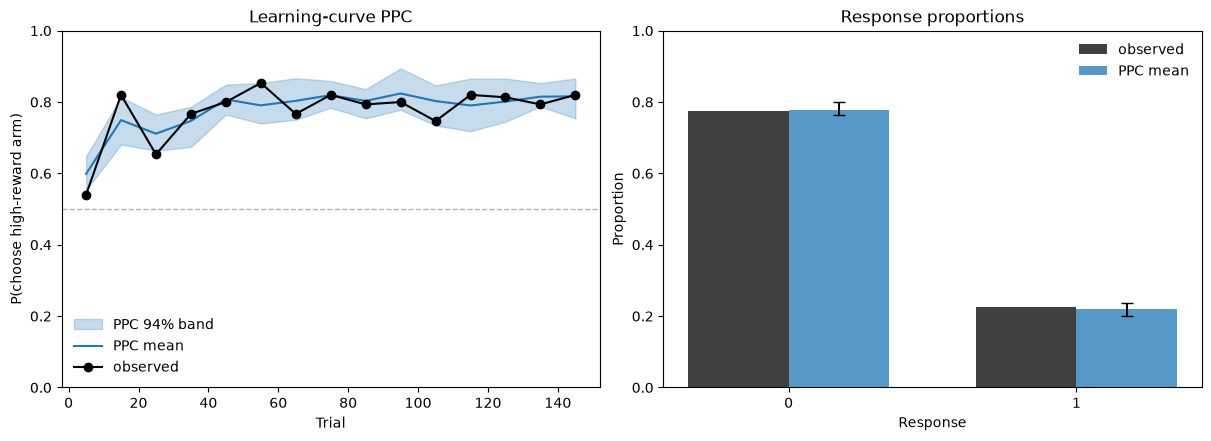

In [16]:
HIGH_REWARD_RESPONSE = 0


def high_reward_curve(df, bin_size=BIN_SIZE):
    """Return binned high-reward response rates."""
    d = df.copy()
    d["chose_high_reward"] = (d["response"].astype(int) == HIGH_REWARD_RESPONSE).astype(
        float
    )
    d["trial_bin"] = (d["trial_id"].astype(int) // bin_size) * bin_size
    return d.groupby("trial_bin")["chose_high_reward"].mean()


def response_proportions(df, choices):
    """Return response proportions indexed by configured choices."""
    return (
        df["response"]
        .astype(int)
        .value_counts(normalize=True)
        .reindex(choices, fill_value=0.0)
        .sort_index()
    )


fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)

obs_curve = high_reward_curve(response_only_data)
ppc_curves = pd.concat(
    [high_reward_curve(g).rename(k) for k, g in ppc_data.groupby("ppc_draw")],
    axis=1,
).sort_index()
x_curve = ppc_curves.index + BIN_SIZE / 2
axes[0].fill_between(
    x_curve,
    ppc_curves.quantile(0.03, axis=1),
    ppc_curves.quantile(0.97, axis=1),
    alpha=0.25,
    color="tab:blue",
    label="PPC 94% band",
)
axes[0].plot(
    x_curve, ppc_curves.mean(axis=1), color="tab:blue", lw=1.5, label="PPC mean"
)
axes[0].plot(
    obs_curve.index + BIN_SIZE / 2,
    obs_curve.values,
    "o-",
    color="black",
    label="observed",
)
axes[0].axhline(0.5, color="0.7", ls="--", lw=1)
axes[0].set(
    xlabel="Trial",
    ylabel="P(choose high-reward arm)",
    title="Learning-curve PPC",
    ylim=(0, 1),
)
axes[0].legend(frameon=False)

choices = list(model_config.choices)
obs_props = response_proportions(response_only_data, choices)
ppc_props = pd.DataFrame(
    [response_proportions(g, choices) for _, g in ppc_data.groupby("ppc_draw")]
)
ppc_mean = ppc_props.mean(axis=0)
ppc_q03 = ppc_props.quantile(0.03, axis=0)
ppc_q97 = ppc_props.quantile(0.97, axis=0)
x = np.arange(len(choices))
width = 0.35
axes[1].bar(
    x - width / 2,
    obs_props.values,
    width=width,
    color="black",
    alpha=0.75,
    label="observed",
)
axes[1].bar(
    x + width / 2,
    ppc_mean.values,
    width=width,
    yerr=[ppc_mean.values - ppc_q03.values, ppc_q97.values - ppc_mean.values],
    capsize=4,
    color="tab:blue",
    alpha=0.75,
    label="PPC mean",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(c) for c in choices])
axes[1].set(
    xlabel="Response", ylabel="Proportion", title="Response proportions", ylim=(0, 1)
)
axes[1].legend(frameon=False)
plt.show()

## Summary

Choice-only RLSSMs use response-only data in HSSM, even though ssms emits `rt=-1.0` for simulator compatibility. The sampled HSSM parameters are the learning rate `rl_alpha` and inverse temperature `beta`; trial-wise Q-values are computed by replaying the observed choice and feedback history.

Related tutorials:

- [Choice-only models](choice_only_models.ipynb) for static choice-only softmax models.
- [RLSSM basic tutorial](rlssm_basic.ipynb) for RT+choice RLSSMs.
- [RLSSM custom models with ssms.rl](rlssm_advanced.ipynb) for custom learning and task components.
- [RLSSM restless learner](rlssm_restless_learner.ipynb) for a richer learning-process example.
